<a href="https://colab.research.google.com/github/ntthang-dev/AI_Control_HCMUT_EE3063_Spring2025/blob/main/hw4_linear_regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4: Linear Regression Algorithm

**Môn học:** HCMUT 242 -  EE3097 -Trí tuệ nhân tạo trong điều khiển

**Họ và Tên:** [Khôi]

**MSSV:** [MSSV]


## Yêu cầu đề bài

* Write a program implementing linear regression algorithm solving a freely chosen problem

## Mục tiêu

* Mô tả ngắn gọn mục tiêu


Intercept (b0): 2014.5902797962706
Slope (b1): 0.00010964011231531975


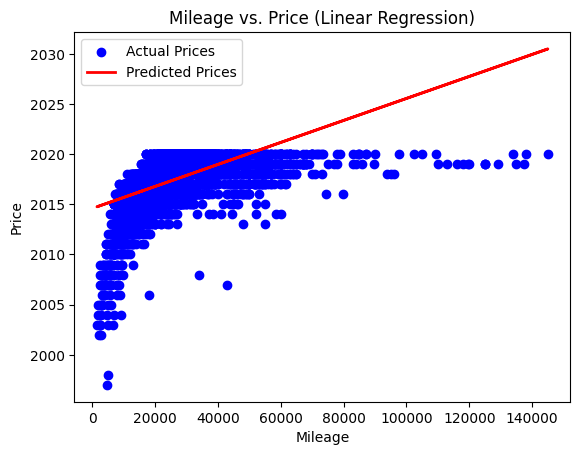

In [5]:
import csv
import requests
import matplotlib.pyplot as plt

# Function to calculate the mean of a list
def mean(data):
    return sum(data) / len(data)

# Function to calculate the variance of a list
def variance(data, mean_data):
    return sum([(x - mean_data)**2 for x in data])

# Function to calculate the covariance between two lists
def covariance(data_x, mean_x, data_y, mean_y):
    covar = 0.0
    for i in range(len(data_x)):
        covar += (data_x[i] - mean_x) * (data_y[i] - mean_y)
    return covar

# Function to calculate coefficients of the linear regression model
def coefficients(data_x, data_y):
    x_mean, y_mean = mean(data_x), mean(data_y)
    b1 = covariance(data_x, x_mean, data_y, y_mean) / variance(data_x, x_mean)
    b0 = y_mean - b1 * x_mean
    return [b0, b1]

# Function to make predictions using the linear regression model
def predict(x, coefficients):
    return coefficients[0] + coefficients[1] * x

# Download the dataset
url = 'https://raw.githubusercontent.com/ntthang-dev/AI_Control_HCMUT_EE3063_Spring2025/main/datasets/audi.csv'
response = requests.get(url)
data = [row for row in csv.reader(response.text.splitlines())]

# Extract mileage and price data
mileage = [float(row[2]) for row in data[1:]]
price = [float(row[1]) for row in data[1:]]

# Calculate coefficients
b0, b1 = coefficients(mileage, price)

# Print coefficients
print(f"Intercept (b0): {b0}")
print(f"Slope (b1): {b1}")

# Make predictions
predictions = [predict(x, [b0, b1]) for x in mileage]

# Plot the results
plt.scatter(mileage, price, color='blue', label='Actual Prices')
plt.plot(mileage, predictions, color='red', linewidth=2, label='Predicted Prices')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Mileage vs. Price (Linear Regression)')
plt.legend()
plt.show()